# 2. Análisis preliminar

Ejecutar después del notebook anterior, con el kernel del `.venv`. La primera celda de código fija la raíz del proyecto y la siguiente carga los datos preparados por la etapa anterior. Reiniciar el kernel y ejecutar todas las celdas para repetir esta etapa.
Los gráficos se guardan también como PNG en `output/graficos/02_analisis_preliminar/`; los dendrogramas conservan además su exportación PDF en `output/dendrogramas/`.


In [1]:
import os
from pathlib import Path

# Permite ejecutar el notebook desde la raíz del proyecto o desde src/.
_directorio = Path.cwd()
if _directorio.name == "src" and (_directorio.parent / "pyproject.toml").is_file():
    os.chdir(_directorio.parent)
elif not (_directorio / "pyproject.toml").is_file():
    raise RuntimeError("Abrí el proyecto desde su raíz o desde src/ antes de ejecutar el notebook.")

In [2]:
import pandas as pd

_estado = pd.read_pickle("output/notebooks/manipulacion.pkl")
alumnos_s_avanzados = _estado["alumnos_s_avanzados"]
alumnos_s_avanzados_desaprob_mat_IS = _estado["alumnos_s_avanzados_desaprob_mat_IS"]
alumnos_desertores = _estado["alumnos_desertores"]


## Importaciones

In [3]:

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from glmnet import LogitNet
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import cut_tree, dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.model_selection import KFold

# Exportar también los gráficos que se muestran en Jupyter.
_directorio_graficos = Path("output/graficos/02_analisis_preliminar")
_directorio_graficos.mkdir(parents=True, exist_ok=True)


def _guardar_grafico(figura, nombre):
    figura.savefig(
        _directorio_graficos / f"{nombre}.png", dpi=160, bbox_inches="tight"
    )


## Porcentajes descriptivos

In [4]:
# Análisis de desertores que desaprobaron materias importantes de Ingeniería en Sistemas

print(
    pd.DataFrame(
        {
            "porc_desertores": [
                (alumnos_s_avanzados_desaprob_mat_IS["deserto"] == True).mean() * 100
            ]
        }
    )
)

# Análisis de desertores que nacieron en la localidad de Tandil (donde se cursa la carrera)

print(
    pd.DataFrame(
        {
            "porc_desertores_fuera_tandil": [
                (
                    (alumnos_desertores["deserto"] == True)
                    & (alumnos_desertores["localidad_nacimiento"] != "TANDIL")
                ).mean()
                * 100
            ]
        }
    )
)


   porc_desertores
0        95.481928
   porc_desertores_fuera_tandil
0                     62.594509


## Preparación de variables para el análisis

In [5]:
# Removemos la información que no es necesario del dataframe para analizar y poner la información en el formato correcto
# Limpieza y selección de variables relevantes
# Objetivo: preparar los datos solo con las variables numéricas necesarias para hacer clustering.
alumnos_s_avanzados = alumnos_s_avanzados.copy()
alumnos_s_avanzados["tiempo_desde_ingreso"] = (
    alumnos_s_avanzados["tiempo_desde_ingreso"].dt.total_seconds() / 86400
)
alumnos_s_avanzados["deserto"] = alumnos_s_avanzados["deserto"].astype(float)
alumnos_s_avanzados["dias_dsd_ultimo_final"] = (
    alumnos_s_avanzados["dias_dsd_ultimo_final"].dt.total_seconds() / 86400
)

# Eliminamos variables que no nos interesan para el análisis

alumnos_s_avanzados = alumnos_s_avanzados.drop(
    columns=[
        "nota_finales_ult_anio",
        "cursadas_regulares",
        "notas_cursadas_ult_anio",
        "relacion_finales_cursadas",
        "porc_cursadas",
        "total_materias_finalizadas",
        "localidad_nacimiento",
        "fecha_inscripcion",
        "cambio_plan",
        "id_alumno",
        "plan",
        "carrera",
        "calidad",
    ]
)


## Regresión logística LASSO

In [6]:
# REGRESIÓN LOGÍSTICA LASSO
# Preparar matrices
X = alumnos_s_avanzados.drop(columns=["deserto"])
y = alumnos_s_avanzados["deserto"]


def _glmnet_deviance_score(model, features, target, lamb):
    """Score binomial deviance using R glmnet's probability bounds."""
    probabilities = model.predict_proba(features, lamb=lamb)[:, 1, :]
    probabilities = np.clip(probabilities, 1e-5, 1 - 1e-5)
    target = np.asarray(target).reshape(-1, 1)
    return 2 * np.mean(
        target * np.log(probabilities) + (1 - target) * np.log1p(-probabilities),
        axis=0,
    )


np.random.seed(1)
# Modelo LASSO
# Particiones aleatorias sin estratificar, como cv.glmnet en R.
particiones_lasso = KFold(n_splits=10, shuffle=True, random_state=1)
grupos_lasso = np.empty(len(X), dtype=int)
for numero_particion, (_, indices_validacion) in enumerate(particiones_lasso.split(X)):
    grupos_lasso[indices_validacion] = numero_particion

# glmnet estandariza internamente y devuelve coeficientes en la escala original.
# cv.glmnet limita probabilidades a [1e-5, 1-1e-5] al calcular la deviance.
# cut_point=0 selecciona el mínimo error, como s="lambda.min" en el original.
modelo_lasso = LogitNet(
    alpha=1,
    n_lambda=100,
    min_lambda_ratio=0.01 if X.shape[0] < X.shape[1] else 0.0001,
    n_splits=10,
    scoring=_glmnet_deviance_score,
    cut_point=0,
    standardize=True,
    fit_intercept=True,
    random_state=1,
).fit(X, y, groups=grupos_lasso)

coeficientes_lasso = pd.Series(
    modelo_lasso.coef_[0],
    index=X.columns,
    name="coeficiente",
)
intercepto_lasso = float(modelo_lasso.intercept_)
coeficientes_lasso = pd.concat(
    [
        pd.Series({"(Intercept)": intercepto_lasso}, name="coeficiente"),
        coeficientes_lasso,
    ]
)
print(coeficientes_lasso)


(Intercept)                  10.795445
tiempo_desde_ingreso          0.000000
cursadas_aprobadas           -0.210440
cursadas_promocionadas       -0.102884
cursadas_desaprobadas        -0.021928
materias_anotado_ult_anio    -3.079274
finales_aprobados             0.000000
finales_desaprobados          0.000000
dias_dsd_ultimo_final         0.000000
porc_finales                 -4.543533
Name: coeficiente, dtype: float64


## Escalado y clustering jerárquico

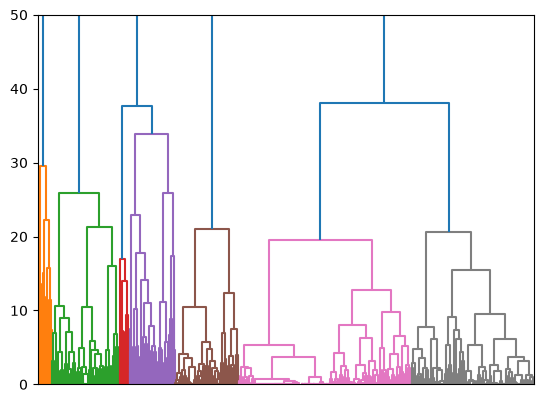

In [7]:
# Configuracion de la semilla aleatoria: Fija la semilla para garantizar que cualquier operación aleatoria (como el dendrograma) sea reproducible.
np.random.seed(1)

# Muestra de una matriz de correlacion para la tabla de alumnos sin recibidos
# Creación de la matriz de correlación y normalización
# Generación del dendograma y la clusterización jerárquica
# La estandarización normaliza las variables (media = 0, desvío estándar = 1).
# corr(): calcula la matriz de correlación entre variables normalizadas y no normalizadas.

alumnos_s_avanzados_sc = (
    alumnos_s_avanzados - alumnos_s_avanzados.mean(axis=0)
) / alumnos_s_avanzados.std(axis=0, ddof=1)
matriz_cor = alumnos_s_avanzados_sc.corr()
matriz_cor_comparacion = alumnos_s_avanzados.corr()
alumnos_s_avanzados_sc.index = np.arange(1, len(alumnos_s_avanzados_sc) + 1)

# Creación de la matriz de distancias y clustering jerárquico
# Calcula las distancias euclideanas entre estudiantes.
# Realiza un clustering jerárquico completo (hclust).
# Corta el dendrograma a una altura h = 35 para formar los clusters.

alumnos_s_avanzados_dist_mat = pdist(
    alumnos_s_avanzados_sc.to_numpy(), metric="euclidean"
)
hclust_alumnos_s_avanzados = linkage(alumnos_s_avanzados_dist_mat, method="ward")
hclustered_alumnos_s_avanzados = (
    cut_tree(hclust_alumnos_s_avanzados, height=35).reshape(-1) + 1
)

# Visualización del dendrograma
# Muestra el árbol de decisión jerárquico coloreado por grupo.
# Ayuda a visualizar cómo se formaron los clusters.

fig_dendrograma, ax_dendrograma = plt.subplots()
dendrogram(
    hclust_alumnos_s_avanzados,
    color_threshold=35,
    no_labels=True,
    ax=ax_dendrograma,
)
ax_dendrograma.set_ylim(0, 50)

# Actualización del dataframe con la información del cluster -> Asignación del cluster a cada alumno
alumnos_s_avanzados["cluster"] = pd.Categorical(hclustered_alumnos_s_avanzados)

# Creación de un resumen de los clusters -> Resumen estadístico por cluster
# Muestra cómo se comportan las variables clave en cada cluster: si son más desertores, si promocionan más materias, etc.

resumen_cluster = (
    alumnos_s_avanzados.groupby("cluster", as_index=False, observed=True)
    .agg(
        cantidad_observaciones=("cluster", "size"),
        media_cursadas_aprobadas=("cursadas_aprobadas", "mean"),
        media_cursadas_desaprobadas=("cursadas_desaprobadas", "mean"),
        media_materias_anotado_ult_anio=("materias_anotado_ult_anio", "mean"),
        media_finales_aprobados=("finales_aprobados", "mean"),
        media_finales_desaprobados=("finales_desaprobados", "mean"),
        media_cursadas_promocionadas=("cursadas_promocionadas", "mean"),
        media_porc_finales=("porc_finales", "mean"),
        media_T_desde_ingreso=("tiempo_desde_ingreso", "mean"),
        media_deserto=("deserto", "mean"),
        media_dias_dsd_ultimo_final=("dias_dsd_ultimo_final", "mean"),
    )
    .copy()
)

_guardar_grafico(fig_dendrograma, "dendrograma_general")


## Dendrogramas de cada clúster

In [8]:
# =====================================
# NUEVO: Dendrogramas individuales por cluster
# =====================================

# Crear carpeta de salida si no existe
Path("output/dendrogramas").mkdir(parents=True, exist_ok=True)

# Los nombres de fila de alumnos_s_avanzados_sc se asignaron de 1 a n para mantener trazabilidad.

# Generar dendrogramas internos y exportar como PDF
for k in sorted(alumnos_s_avanzados["cluster"].unique()):
    print("Generando dendrograma para cluster:", k)
    idx = alumnos_s_avanzados["cluster"].astype(int).to_numpy() == k
    datos_cluster = alumnos_s_avanzados_sc.iloc[np.flatnonzero(idx)]

    if len(datos_cluster) > 2:
        dist_cl = pdist(datos_cluster.to_numpy())
        hc_cl = linkage(dist_cl, method="ward")

        # Cortar en 4 subgrupos internos para análisis
        subgrupos = cut_tree(hc_cl, n_clusters=4).reshape(-1) + 1

        # Guardar dendrograma completo con rectángulos por subgrupo
        fig_cluster, ax_cluster = plt.subplots(figsize=(15, 10))
        dend_cluster = dendrogram(
            hc_cl,
            no_labels=True,
            ax=ax_cluster,
        )
        ax_cluster.set_title(f"Dendrograma interno - Cluster {k}")
        ax_cluster.set_ylabel("Altura (distancia)")

        posiciones_hojas = {
            hoja: 5 + posicion * 10
            for posicion, hoja in enumerate(dend_cluster["leaves"])
        }
        altura_rectangulos = hc_cl[-3, 2]
        colores_rectangulos = ["red", "green", "blue", "cyan"]
        grupos_con_posicion = []
        for grupo in np.unique(subgrupos):
            posicion_inicial = min(
                posiciones_hojas[indice]
                for indice in np.flatnonzero(subgrupos == grupo)
            )
            grupos_con_posicion.append((posicion_inicial, grupo))
        grupos_ordenados = [grupo for _, grupo in sorted(grupos_con_posicion)]
        for numero_grupo, grupo in enumerate(grupos_ordenados):
            posiciones_grupo = [
                posiciones_hojas[indice]
                for indice in np.flatnonzero(subgrupos == grupo)
            ]
            ax_cluster.add_patch(
                Rectangle(
                    (min(posiciones_grupo) - 4, 0),
                    max(posiciones_grupo) - min(posiciones_grupo) + 8,
                    altura_rectangulos,
                    fill=False,
                    edgecolor=colores_rectangulos[numero_grupo],
                )
            )

        fig_cluster.savefig(
            f"output/dendrogramas/dendrograma_cluster_{k}.pdf",
            format="pdf",
        )
        _guardar_grafico(fig_cluster, f"dendrograma_cluster_{k}")
        plt.close(fig_cluster)

        # Guardar dendrograma con zoom (primeros 50 casos si hay suficientes)
        if len(datos_cluster) >= 500:
            datos_subset = datos_cluster.iloc[:50]
            hc_subset = linkage(pdist(datos_subset.to_numpy()), method="ward")
            subgrupos_subset = cut_tree(hc_subset, n_clusters=3).reshape(-1) + 1

            fig_subset, ax_subset = plt.subplots(figsize=(12, 8))
            dend_subset = dendrogram(
                hc_subset,
                labels=datos_subset.index.astype(str).to_list(),
                leaf_font_size=7,
                ax=ax_subset,
            )
            ax_subset.set_title(f"Zoom - Cluster {k} (Primeros 50 casos)")
            ax_subset.set_ylabel("Altura (distancia)")

            posiciones_hojas_subset = {
                hoja: 5 + posicion * 10
                for posicion, hoja in enumerate(dend_subset["leaves"])
            }
            altura_rectangulos_subset = hc_subset[-2, 2]
            grupos_subset_con_posicion = []
            for grupo in np.unique(subgrupos_subset):
                posicion_inicial = min(
                    posiciones_hojas_subset[indice]
                    for indice in np.flatnonzero(subgrupos_subset == grupo)
                )
                grupos_subset_con_posicion.append((posicion_inicial, grupo))
            grupos_subset_ordenados = [
                grupo for _, grupo in sorted(grupos_subset_con_posicion)
            ]
            for numero_grupo, grupo in enumerate(grupos_subset_ordenados):
                posiciones_grupo = [
                    posiciones_hojas_subset[indice]
                    for indice in np.flatnonzero(subgrupos_subset == grupo)
                ]
                ax_subset.add_patch(
                    Rectangle(
                        (min(posiciones_grupo) - 4, 0),
                        max(posiciones_grupo) - min(posiciones_grupo) + 8,
                        altura_rectangulos_subset,
                        fill=False,
                        edgecolor=colores_rectangulos[numero_grupo],
                    )
                )

            fig_subset.savefig(
                f"output/dendrogramas/dendrograma_zoom_cluster_{k}.pdf",
                format="pdf",
            )
            _guardar_grafico(fig_subset, f"dendrograma_zoom_cluster_{k}")
            plt.close(fig_subset)
    else:
        print("Cluster", k, "tiene muy pocos elementos para dendrograma.")


Generando dendrograma para cluster: 1


Generando dendrograma para cluster: 2
Generando dendrograma para cluster: 3


Generando dendrograma para cluster: 4
Generando dendrograma para cluster: 5


Generando dendrograma para cluster: 6


Generando dendrograma para cluster: 7


## Exportación del resumen de clústeres

In [9]:
# Para exportar el resumen de los clusters formados por el clustering jerarquico
resumen_cluster_exportacion = resumen_cluster.copy()
resumen_cluster_exportacion["cluster"] = resumen_cluster_exportacion["cluster"].astype(
    str
)
resumen_cluster_exportacion.to_csv(
    "resumen_clusters.csv",
    index=False,
    quoting=csv.QUOTE_NONNUMERIC,
)


## Validación con Silhouette

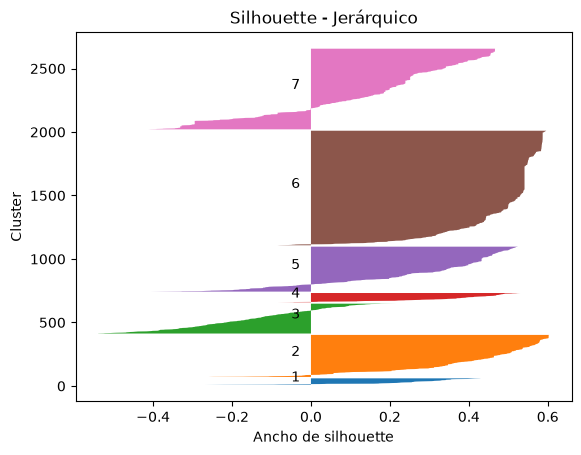

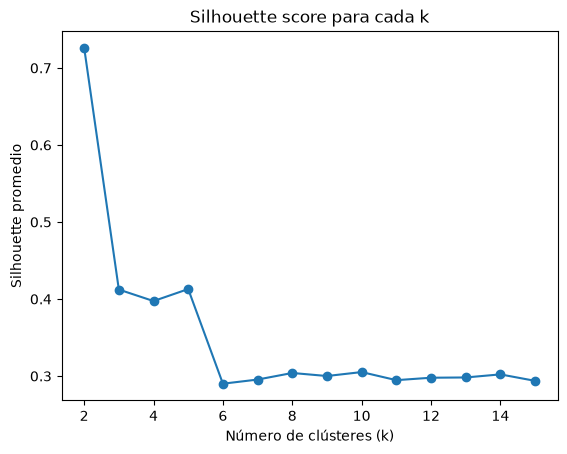

In [10]:
# ------------------------------
# Validación de agrupamientos
# ------------------------------

# Silhouette para jerárquico
_matriz_distancias = squareform(alumnos_s_avanzados_dist_mat)
_clusters_jerarquicos = alumnos_s_avanzados["cluster"].astype(int).to_numpy()
sil_h = silhouette_samples(
    _matriz_distancias,
    _clusters_jerarquicos,
    metric="precomputed",
)

fig_silhouette, ax_silhouette = plt.subplots()
posicion_inferior = 10
for k in sorted(np.unique(_clusters_jerarquicos)):
    valores_cluster = np.sort(sil_h[_clusters_jerarquicos == k])
    posicion_superior = posicion_inferior + len(valores_cluster)
    ax_silhouette.fill_betweenx(
        np.arange(posicion_inferior, posicion_superior),
        0,
        valores_cluster,
    )
    ax_silhouette.text(-0.05, posicion_inferior + len(valores_cluster) / 2, str(k))
    posicion_inferior = posicion_superior + 10
ax_silhouette.set_title("Silhouette - Jerárquico")
ax_silhouette.set_xlabel("Ancho de silhouette")
ax_silhouette.set_ylabel("Cluster")

###########################################################
# Encontrar el mejor valor de k, usando Silhouette Score
###########################################################

sil_scores = np.full(16, np.nan)
for k in range(2, 16):
    clust_temp = cut_tree(hclust_alumnos_s_avanzados, n_clusters=k).reshape(-1) + 1
    sil_scores[k] = silhouette_score(
        _matriz_distancias,
        clust_temp,
        metric="precomputed",
    )

# Graficar resultados
fig_sil_scores, ax_sil_scores = plt.subplots()
ax_sil_scores.plot(range(2, 16), sil_scores[2:16], marker="o")
ax_sil_scores.set_xlabel("Número de clústeres (k)")
ax_sil_scores.set_ylabel("Silhouette promedio")
ax_sil_scores.set_title("Silhouette score para cada k")

_guardar_grafico(fig_silhouette, "silhouette_jerarquico")
_guardar_grafico(fig_sil_scores, "silhouette_por_k")


## Visualización de perfiles

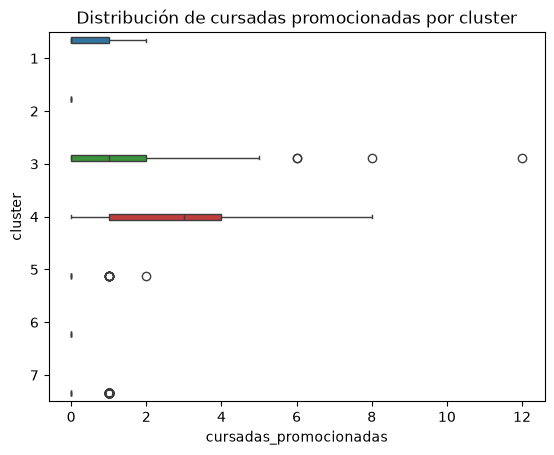

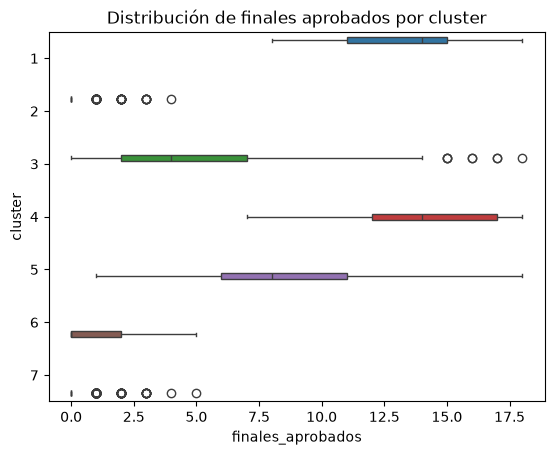

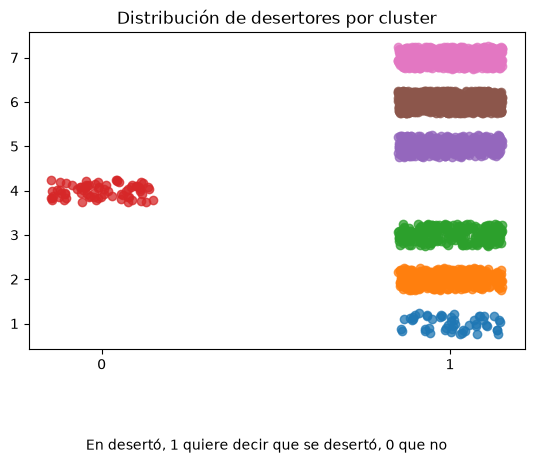

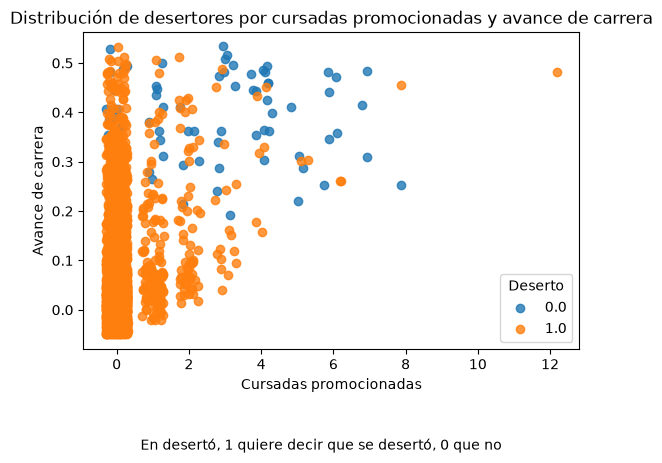

In [11]:
####################################################################################################
# Parte del anterior trabajo
####################################################################################################

# Visualizaciones para análisis de clusters a través de tres graficos que relacionan clusters con cursadas promocionadas finales aprobados, y deserción

# Distribución de cursadas promocionadas
fig_promocionadas, ax_promocionadas = plt.subplots()
sns.boxplot(
    data=alumnos_s_avanzados,
    x="cursadas_promocionadas",
    y="cluster",
    hue="cluster",
    legend=False,
    ax=ax_promocionadas,
)
ax_promocionadas.set_title("Distribución de cursadas promocionadas por cluster")

# Distribución de finales aprobados
fig_finales, ax_finales = plt.subplots()
sns.boxplot(
    data=alumnos_s_avanzados,
    x="finales_aprobados",
    y="cluster",
    hue="cluster",
    legend=False,
    ax=ax_finales,
)
ax_finales.set_title("Distribución de finales aprobados por cluster")

# Distribución de deserción por grupo
_generador_aleatorio = np.random.default_rng(1)
fig_desercion, ax_desercion = plt.subplots()
for posicion_cluster, k in enumerate(sorted(alumnos_s_avanzados["cluster"].unique())):
    datos_cluster = alumnos_s_avanzados[alumnos_s_avanzados["cluster"].astype(int) == k]
    ax_desercion.scatter(
        datos_cluster["deserto"]
        + _generador_aleatorio.uniform(-0.15, 0.15, len(datos_cluster)),
        posicion_cluster
        + _generador_aleatorio.uniform(-0.25, 0.25, len(datos_cluster)),
        alpha=0.75,
        label=str(k),
    )
ax_desercion.set_xticks([0, 1])
ax_desercion.set_yticks(
    range(len(alumnos_s_avanzados["cluster"].cat.categories)),
    alumnos_s_avanzados["cluster"].cat.categories,
)
ax_desercion.set_title("Distribución de desertores por cluster")
fig_desercion.text(
    0.5,
    0.01,
    "En desertó, 1 quiere decir que se desertó, 0 que no ",
    ha="center",
)

# Avance vs. promocionadas y deserción
fig_avance, ax_avance = plt.subplots()
for valor_deserto in sorted(alumnos_s_avanzados["deserto"].unique()):
    datos_desercion = alumnos_s_avanzados[
        alumnos_s_avanzados["deserto"] == valor_deserto
    ]
    ax_avance.scatter(
        datos_desercion["cursadas_promocionadas"]
        + _generador_aleatorio.uniform(-0.3, 0.3, len(datos_desercion)),
        datos_desercion["porc_finales"]
        + _generador_aleatorio.uniform(-0.05, 0.05, len(datos_desercion)),
        alpha=0.8,
        label=str(valor_deserto),
    )
ax_avance.set_title(
    "Distribución de desertores por cursadas promocionadas y avance de carrera",
    fontsize=12,
)
ax_avance.set_ylabel("Avance de carrera")
ax_avance.set_xlabel("Cursadas promocionadas")
ax_avance.legend(title="Deserto")
fig_avance.text(
    0.5,
    0.01,
    "En desertó, 1 quiere decir que se desertó, 0 que no ",
    ha="center",
)

# Reservar espacio para que los textos explicativos no se superpongan al eje.
fig_desercion.subplots_adjust(bottom=0.22)
fig_avance.subplots_adjust(bottom=0.22)

_guardar_grafico(fig_promocionadas, "cursadas_promocionadas_por_cluster")
_guardar_grafico(fig_finales, "finales_aprobados_por_cluster")
_guardar_grafico(fig_desercion, "desercion_por_cluster")
_guardar_grafico(fig_avance, "avance_vs_promocionadas")

plt.show()


## Datos para el análisis extra

In [12]:
Path("output/notebooks").mkdir(parents=True, exist_ok=True)
pd.to_pickle(
    {
        "alumnos_s_avanzados": alumnos_s_avanzados,
        "alumnos_s_avanzados_sc": alumnos_s_avanzados_sc,
        "alumnos_s_avanzados_dist_mat": alumnos_s_avanzados_dist_mat,
    },
    "output/notebooks/analisis_preliminar.pkl",
)
